<a href="https://colab.research.google.com/github/Zineb9876/Projet-Deep-Learning/blob/main/Exercice3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Importer les bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
## uploader le fichier

from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing (1).csv


In [ ]:
## Charger la dataset
import pandas as pd

df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


1. On peut vérifier que toutes les colonnes attendues sont présentes :
price, area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus

2. Vérifie que les données ne contiennent pas d’erreurs d’import (ex : colonnes vides ou mauvaises valeurs)

In [ ]:
## Vérifier les valeurs manquantes

VM = pd.DataFrame({
'Colonne': df.columns.values,
'nbr_VM': df.isna().sum().values,
'%_VM': 100 * df.isna().sum().values / len(df)
})

VM = VM[VM['nbr_VM'] > 0]

print(VM.sort_values(by='nbr_VM', ascending=False).reset_index(drop=True))

Empty DataFrame
Columns: [Colonne, nbr_VM, %_VM]
Index: []


In [ ]:
## Encoder les colonnes catégorielles

# Colonnes oui/non
yes_no_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']

for col in yes_no_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Encodage automatique de toutes les autres colonnes de type object
cat_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

1. Permet au modèle Deep Learning de traiter toutes les données comme des nombres.

2. Évite l’erreur.

3. Vérifie le nombre de colonnes après encodage : il peut augmenter selon les catégories uniques.

In [ ]:
## Séparer la variable cible et les caractéristiques

y = df['price']
X = df.drop('price', axis=1)

1.  y sera la variable à prédire

2.  X sera utilisée pour entraîner le modèle

3.  Vérifie que price n’est pas incluse dans X pour éviter le leakage.

In [ ]:
## Fractionner en données d'entraînement et de test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Taille du train :", X_train.shape)
print("Taille du test  :", X_test.shape)

Taille du train : (436, 13)
Taille du test  : (109, 13)


1.  Permet d’entraîner le modèle sur une partie des données et de tester sa performance sur une partie jamais vue.

2.  Vérifie la taille des jeux pour t’assurer qu’il y a suffisamment de données dans chacun.

In [ ]:
## Remplacer les NaN restants par 0
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

In [ ]:
## Standardiser les variables

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

1.  Toutes les colonnes ont une moyenne proche de 0 et un écart-type proche de 1

2.  Permet au modèle Deep Learning d’apprendre plus efficacement.

3.  Évite que certaines colonnes avec des grandes valeurs dominent l’apprentissage.

In [ ]:
## Construire le modèle Deep Learning avec Adam

model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),  # couche d'entrée propre
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # prédiction du price
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

1.  Création d’un modèle avec 3 couches cachées + Dropout + 1 couche de sortie.

2.  128 → 64 → 32 → 1 : architecture simple mais efficace pour ce dataset.

3.  Dropout 0.3 : réduit le risque d’overfitting.

4.  Optimiseur Adam : ajuste automatiquement le taux d’apprentissage pour un meilleur résultat.

In [ ]:
## Entraîner le modèle
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 23966445993984.0000 - mae: 4593872.5000 - val_loss: 24781596393472.0000 - val_mae: 4623896.5000
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25604627890176.0000 - mae: 4731557.5000 - val_loss: 24781590102016.0000 - val_mae: 4623896.5000
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24498298421248.0000 - mae: 4658979.0000 - val_loss: 24781573324800.0000 - val_mae: 4623894.5000
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26903037607936.0000 - mae: 4837154.0000 - val_loss: 24781533478912.0000 - val_mae: 4623891.0000
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 23807855165440.0000 - mae: 4584124.5000 - val_loss: 24781466370048.0000 - val_mae: 4623884.0000
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25534606082048.0000 - mae: 4757934.0000 - val_loss: 24781342638080.0000 - val_mae: 4623871.5000
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2516007570

1. La loss diminue progressivement → le modèle apprend.

2. La MAE diminue → les prédictions deviennent plus proches des valeurs réelles.

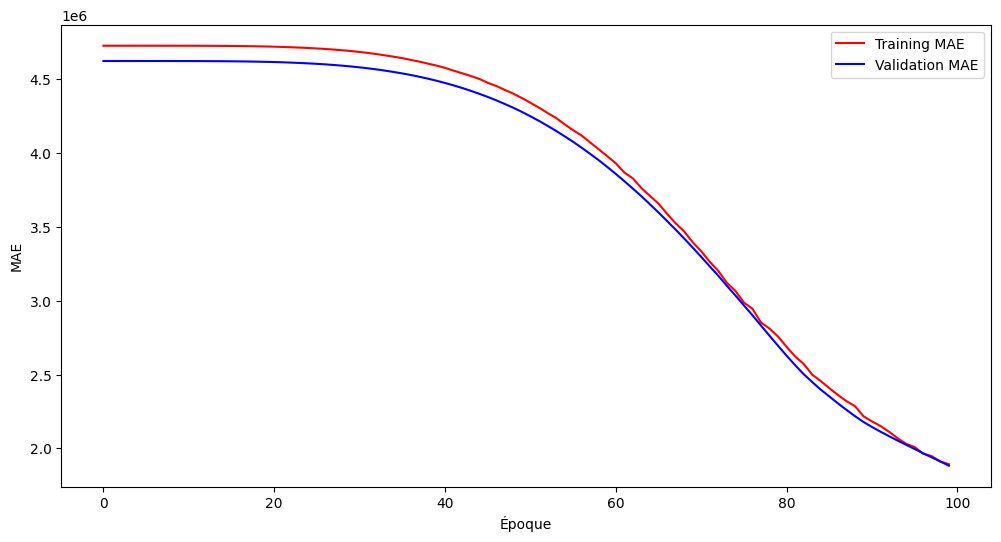

In [ ]:
## Visualiser la performance (MAE)

historique = pd.DataFrame(history.history)

plt.figure(figsize=(12,6))
plt.plot(historique['mae'], label='Training MAE', color='red')
plt.plot(historique['val_mae'], label='Validation MAE', color='blue')
plt.xlabel('Époque')
plt.ylabel('MAE')
plt.legend()
plt.show()

1.  Permet de vérifier la convergence du modèle.


In [ ]:
## Tester le modèle sur une observation

# Exemple : 10ème observation
test1 = X_test[10].reshape(1, -1)

prediction = model.predict(test1).squeeze()
valeur_reelle = y_test.iloc[10]

print("Prédiction du modèle = {:.2f}".format(prediction))
print("Valeur réelle = {:.2f}".format(valeur_reelle))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Prédiction du modèle = 13211905.00
Valeur réelle = 10150000.00


Vérifie que le modèle prédit des valeurs proches de la réalité.